## Contour line styles

This notebook shows how to customise contour levels, line widths and
line styles.

In [1]:
import earthkit.data as ekd
import earthkit.plots as ekp

data = ekd.from_source("sample", "era5-2t-msl-1985122512.grib").to_fieldlist()
pressure = data.sel({"parameter.variable": "msl"})
temperature = data.sel({"parameter.variable": "2t"})

### Contour levels

You can specify levels in two ways.

**As a range or list** – useful when you know exactly which values you
want:

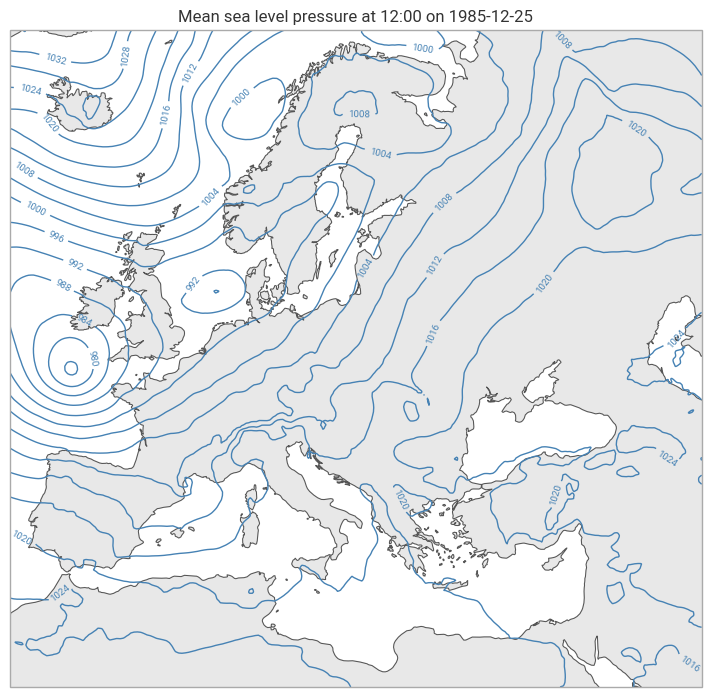

In [2]:
chart = ekp.Map(domain="Europe")
chart.contour(pressure, units="hPa", levels=range(960, 1050, 4), colors="steelblue")
chart.land()
chart.coastlines()
chart.title()
chart.show()

**As a dict** with `step` and `reference` keys – useful when you want
evenly spaced levels anchored to a round number.  Here a 4 hPa step
anchored at 1000 hPa ensures that isobar always appears:

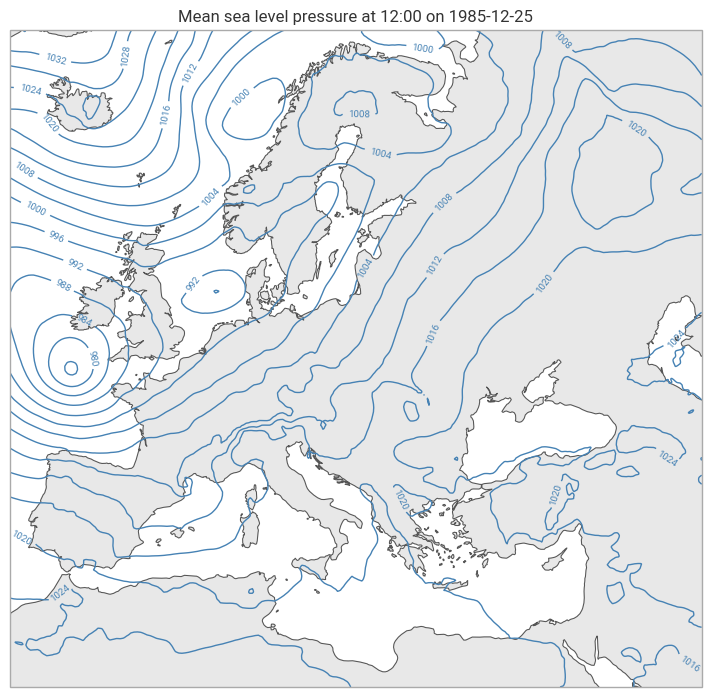

In [3]:
chart = ekp.Map(domain="Europe")
chart.contour(
    pressure,
    units="hPa",
    levels={"step": 4, "reference": 1000},
    colors="steelblue",
)
chart.land()
chart.coastlines()
chart.title()
chart.show()

### Line widths

Pass a single value or a list to `linewidths`.  A list cycles through
the values for successive contour levels – for example, to make every
fourth isobar stand out:

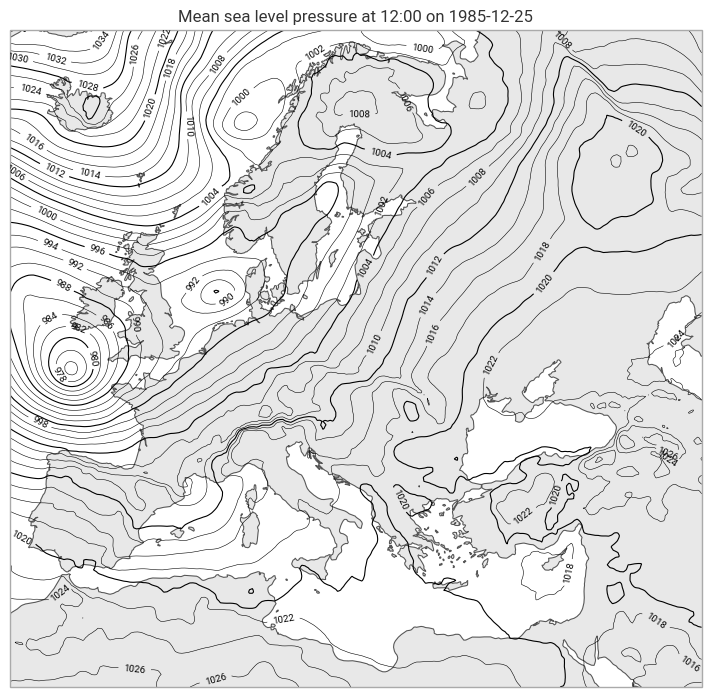

In [4]:
chart = ekp.Map(domain="Europe")
chart.contour(
    pressure,
    units="hPa",
    levels={"step": 2, "reference": 1000},
    colors="black",
    linewidths=[0.4, 0.4, 0.4, 0.8],  # every 4th line is thicker
)
chart.land()
chart.coastlines()
chart.title()
chart.show()

### Line styles

`linestyles` works the same way as `linewidths` – pass a list and it
cycles.  Here we plot 2 °C temperature contours in red, alternating
solid and dashed lines:

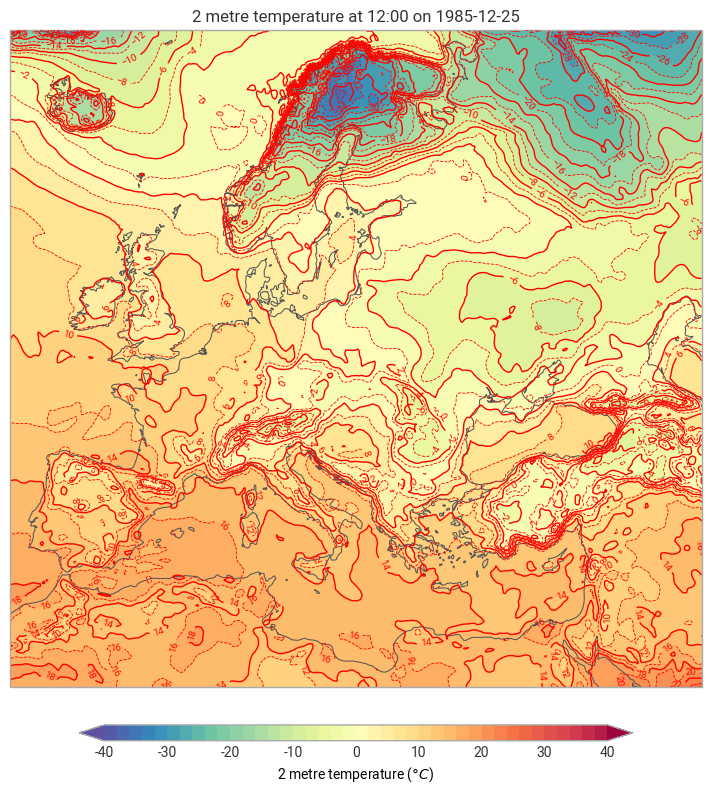

In [5]:
chart = ekp.Map(domain="Europe")

chart.plot(temperature, units="celsius")

chart.contour(
    temperature,
    units="celsius",
    levels={"step": 2, "reference": 0},
    colors="red",
    linewidths=[1, 0.6],
    linestyles=["solid", "dashed"],
    legend_style=None,  # turn off the legend for this layer
)

chart.legend()

chart.land()
chart.coastlines()
chart.title()
chart.show()

### What's next?

The next notebook shows how to encapsulate all of these options into a
reusable `Style` object.